In [44]:
%matplotlib inline
import emcee
import corner
import time
import numpy as np
import scipy.optimize as op
import matplotlib.pyplot as pl
from matplotlib.ticker import MaxNLocator
import scipy.integrate as integrate
import scipy.linalg as linalg
from multiprocessing.pool import ThreadPool
import os
from getdist import plots, MCSamples
import getdist, IPython
from scipy.integrate import quad
from scipy.special import gamma

global argsortz

os.environ["OMP_NUM_THREADS"] = "1"

pl.rcParams.update({
    "text.usetex": True,                # Usa o motor LaTeX para escrever tudo
    "font.family": "serif",             # Usa fonte serifada
    "font.serif": ["Palatino"],         # Especifica a fonte padrão do LaTeX
    "axes.labelsize": 16,               # Tamanho dos rótulos (H0, Wm)
    "font.size": 14,                    # Tamanho geral
    "legend.fontsize": 14,              # Tamanho da legenda
    "xtick.labelsize": 12,              # Tamanho dos números no eixo X
    "ytick.labelsize": 12,              # Tamanho dos números no eixo Y
})

In [3]:
snnamei,zsni,mBi,smBi = np.genfromtxt("data/pantheon_full.txt", unpack=True)
snnamei,zsni,mui,smui = np.genfromtxt("data/pantheon_fullSorted.txt", unpack=True)
covsysraw = np.genfromtxt("data/pantheon_sys_full.txt", unpack=True)

nsn = len(snnamei)
argsortz = np.argsort(zsni)

In [4]:
c = 299792.458#km/s
wr = 9.2364e-5
wb = .0493

In [5]:
covsyspanth = np.zeros((nsn,nsn))
k = 0
for i in range(nsn):
    for j in range(nsn):
        covsyspanth[i,j] = covsysraw[k]
        k=k+1

covstatpanth = np.diag(smBi**2)
covpanth = covstatpanth + covsyspanth

covpanthsort = np.zeros((nsn,nsn))
for i in range(nsn):
    for j in range(nsn):
        covpanthsort[i,j]=covpanth[argsortz[i],argsortz[j]]

invcovsort = linalg.inv(covpanthsort)

In [6]:
#E(z)^2
def Ez2(z,pars):
    if len(pars)==4:
        H0, wm, wl, f = pars
    else:
        H0, wm, wl = pars
    return wm*(1+z)**3+(1-wm-wl)*(1+z)**2+wl

#E(z)^(-1)
def Ez_1(z,pars):
    if len(pars)==4:
        H0, wm, wl, f = pars
    else:
        H0, wm, wl = pars
    return 1./np.sqrt(wm*(1+z)**3+(1-wm-wl)*(1+z)**2+wl)

def odesys(y, z, pars):
    dydz = Ez_1(z,pars)
    return dydz

def solsys(y0, z, pars):
    return integrate.odeint(odesys, y0, z, args=(pars,), atol=1e-6)

#Distancia comovel de linha-de-visada adimensional (=dc/dH)
def Dcmodel(z,pars):
    y0 = 0.
    z = np.append([0.],z)
    sol = solsys(y0, z, pars)[:,0]
    sol = np.delete(sol,0)
    return sol

#Distancia comovel transversal adimensional (=dm/dH)
def Dmmodel(z,pars):
    if len(pars)==4:
        H0, wm, wl, f = pars
    else:
        H0, wm, wl = pars
    wk = 1. - wm - wl
    Dcm = Dcmodel(z,pars)
    if wk < 0:
        return np.sin(np.sqrt(-wk)*Dcm)/np.sqrt(-wk)
    elif wk > 0:
        return np.sinh(np.sqrt(wk)*Dcm)/np.sqrt(wk)
    return Dcm

def Dlmodel(z,pars):
    return (1+z)*Dmmodel(z,pars)

#Distancia comovel transversal in Mpc
def dmmodel(z,pars):
    if len(pars)==4:
        H0, wm, wl, f = pars
    else:
        H0, wm, wl = pars
    dH = c/H0
    wk = 1. - wm - wl
    Dcm = Dcmodel(z,pars)
    if wk < 0:
        return dH*np.sin(np.sqrt(-wk)*Dcm)/np.sqrt(-wk)
    elif wk > 0:
        return dH*np.sinh(np.sqrt(wk)*Dcm)/np.sqrt(wk)
    return dH*Dcm

def dlmodel(z,pars):
    return (1+z)*dmmodel(z,pars)

In [46]:
#Distribution funcion for chi2
def chiDist(chi, n):
    return (n**(n/2)*((chi)**((n-2)/2))*np.exp(-(n/2)*chi))/(2**(n/2)*gamma(n/2))

#Calculate cdf for chiDist
def chiCDF(x, n):
    res = np.zeros_like(x)
    for i, val in enumerate(x):
        y, err = quad(chiDist, 0, val, args=(n))
        res[i]=y
    return res

#Plot chi2 cdf
def plotChiDist(chimin, par, name=0):
    n = ndata - par
    chi = np.linspace(0, 2.5, 500)
    chiv = np.full((500), chimin/n)
    hv = chiDist2(chi, n)
    cdf = chiCDF(chi, n)
    y = np.linspace(0, 1.8, 500)
    
    pl.plot(chi, hv, label=r"$h _{\nu}$")
    pl.plot(chiv, y, '--', label=r"$\chi _{\nu} ^{2}$" + "$= {0}$".format(np.round(chimin/n, 3)))
    pl.plot(chi, cdf, '--', label="cdf")
    
    pl.xticks(np.arange(0.0, 2.51, 0.5))
    pl.yticks(np.arange(0.0, 1.76, 0.25))
    pl.axis((0, 2.5, 0, 1.75))
    pl.grid(linestyle='-.', linewidth='0.5')
    pl.minorticks_on()
    
    pl.ylabel(r'$h_{\nu}$')
    pl.xlabel(r'$\chi _{\nu} ^{2}$')
    pl.legend(loc='best')
   
    if not name == 0:
        pl.savefig('fig/'+name+'.pdf')
    
    pl.show()

from scipy.special import gammaln

def chiDist2(chi, n):
    # Calculate the natural log of the numerator terms
    # Term 1: n^(n/2) -> (n/2) * ln(n)
    # Term 2: chi^((n-2)/2) -> ((n-2)/2) * ln(chi)
    # Term 3: exp(-(n/2)*chi) -> -(n/2) * chi
    log_numerator = (n/2)*np.log(n) + ((n-2)/2)*np.log(chi) - (n/2)*chi
    
    # Calculate the natural log of the denominator terms
    # Term 1: 2^(n/2) -> (n/2) * ln(2)
    # Term 2: gamma(n/2) -> gammaln(n/2)
    log_denominator = (n/2)*np.log(2) + gammaln(n/2)
    
    # Subtract denominator from numerator (equivalent to division)
    log_val = log_numerator - log_denominator
    
    # Return the exponentiated result
    return np.exp(log_val)

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln, gammainc

def chiPDF_robust(chi, n):
    """
    Computes the PDF using the log-sum-exp trick to avoid Overflow.
    Handles chi=0 safely.
    """
    # Ensure input is an array for boolean indexing
    chi = np.asarray(chi, dtype=float)
    res = np.zeros_like(chi)
    
    # 1. Handle chi > 0 (avoid log(0) error)
    mask = chi > 0
    
    # 2. Compute Log-PDF only on safe values
    # We use the log version of your formula:
    # log(P) = (n/2)ln(n) + ((n-2)/2)ln(chi) - (n/2)chi - [(n/2)ln(2) + gammaln(n/2)]
    
    chi_safe = chi[mask]
    
    log_numerator = (n/2)*np.log(n) + ((n-2)/2)*np.log(chi_safe) - (n/2)*chi_safe
    log_denominator = (n/2)*np.log(2) + gammaln(n/2)
    
    res[mask] = np.exp(log_numerator - log_denominator)
    
    # For n=2, the limit at chi=0 is finite (1.0), but for n>2 it is 0.
    # The zeros_like initialization handles the 0 case for n>2 automatically.
    # If you expect n=2 often, you can add: if n==2: res[~mask] = n/2
    
    return res

def chiCDF_robust(chi, n):
    """
    Computes CDF using the Regularized Lower Incomplete Gamma Function.
    This replaces 'quad' integration. It is instantaneous and exact.
    """
    # Your PDF corresponds to a Gamma distribution with shape=n/2 and rate=n/2
    return gammainc(n/2, (n/2) * chi)

# --- usage in your plotting function ---

def plotChiDist(chimin, par, name=None):
    n = par # assuming par is the degrees of freedom
    chi = np.linspace(0, 2.5, 500)
    
    # Use the new robust functions
    hv = chiPDF_robust(chi, n) 
    cdf = chiCDF_robust(chi, n) # No more quad!
    
    # Plotting code...
    plt.plot(chi, hv, label=r"$h_{\nu}$")
    plt.plot(chi, cdf, label="CDF")
    plt.legend()
    plt.show()

In [40]:
theta1 = [74.92363, 0.34356, 0.81675]
theta = [74.99617, 0.34271, 0.81519, 1.05021]

chi1 = chi2snproj1(theta1)
chi = chi2snproj(theta)

ndata = len(snnamei)

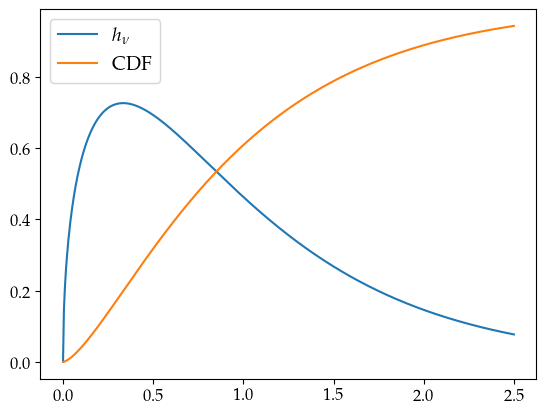

In [49]:
plotChiDist(chi1, len(parnames1))

In [7]:
def chi2snproj1(theta):
    Ez2i = Ez2(zsni,theta)
    if np.any(Ez2i<0):
        return np.inf
    Dlmodi = Dlmodel(zsni,theta)
    if np.any(Dlmodi<=0):
        return np.inf
    mBmod = 5.*np.log10(Dlmodi)
    dmu = mBmod-mui#delta r
    SA  = np.sum(invcovsort)
    Sr  = np.sum(np.dot(dmu.T,invcovsort))
    Srr = np.dot(np.dot(dmu.T,invcovsort),dmu)
    return Srr - Sr**2./SA

def chi2snproj(theta):
    H0, wm, wl, f = theta
    Ez2i = Ez2(zsni,theta)
    if np.any(Ez2i<0):
        return np.inf
    Dlmodi = Dlmodel(zsni,theta)
    if np.any(Dlmodi<=0):
        return np.inf
    mBmod = 5.*np.log10(Dlmodi)
    dmu = mBmod-mui#delta r
    invcovcorr = invcovsort/f**2
    SA  = np.sum(invcovcorr)
    Sr  = np.sum(np.dot(dmu.T,invcovcorr))
    Srr = np.dot(np.dot(dmu.T,invcovcorr),dmu)
    return Srr - Sr**2./SA

In [8]:
par0 = [70, .31, .73, 1.1]
print(chi2snproj(par0))

953.2353805378079


In [9]:
def chi2snproj1(theta):
    Ez2i = Ez2(zsni,theta)
    if np.any(Ez2i<0):
        return np.inf
    Dlmodi = Dlmodel(zsni,theta)
    if np.any(Dlmodi<=0):
        return np.inf
    mBmod = 5.*np.log10(Dlmodi)
    dmu = mBmod-mui#delta r
    SA  = np.sum(invcovsort)
    Sr  = np.sum(np.dot(dmu.T,invcovsort))
    Srr = np.dot(np.dot(dmu.T,invcovsort),dmu)
    return Srr - Sr**2./SA

def chi2snproj(theta):
    H0, wm, wl, f = theta
    Ez2i = Ez2(zsni,theta)
    if np.any(Ez2i<0):
        return np.inf
    Dlmodi = Dlmodel(zsni,theta)
    if np.any(Dlmodi<=0):
        return np.inf
    mBmod = 5.*np.log10(Dlmodi)
    dmu = mBmod-mui#delta r
    invcovcorr = invcovsort/f**2
    SA  = np.sum(invcovcorr)
    Sr  = np.sum(np.dot(dmu.T,invcovcorr))
    Srr = np.dot(np.dot(dmu.T,invcovcorr),dmu)
    return Srr - Sr**2./SA
# Define the probability function as likelihood * prior.    
def lnprior1(theta):
    H0, wm, wl = theta
    if 0.0 < wm < 3.0 and 50. < H0 < 100. and -1.0 < wl < 3.0:
        return 0.0    #flat prior
    return -np.inf

def lnlike1(theta):
    chi2 = chi2snproj1(theta)
    return -0.5*chi2
 
def lnprob1(theta):
    lp = lnprior1(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike1(theta)

def lnprior(theta):
    H0, wm, wl, f = theta
    if 0.0 < wm < 3.0 and 50. < H0 < 100. and -1.0 < wl < 3.0 and .1 < f < 5:
        return 0.0    #flat prior
    return -np.inf

ndata = len(invcovsort)

def lnlike(theta):
    H0, wm, wl, f = theta
    return -.5*(chi2snproj(theta))-ndata*np.log(f)
 
def lnprob(theta):
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta)

In [10]:
# Find the maximum likelihood value.
def find_bestfit(lnlike,par_ml):#,data):
    t1 = time.time()
    ndim = len(par_ml)
    chi2 = lambda *args: -2 * lnlike(*args)
    result = op.minimize(chi2, par_ml)#, args=data)
    if not result['success']:
        result = op.minimize(chi2, par_ml,method='Nelder-Mead',options={'maxiter': 10000})#, args=data
    par_ml = result["x"]
    print('Maximum likelihood result:')
    for i in range(ndim):
        print(parnames[i],' = ',par_ml[i])
    print('chi2min =',result['fun'])
    #ndof = len(data[0])-ndim
    #print('chi2red =',result['fun']/ndof)
    #print(result)
    t2 = time.time()
    print("tempo total: {0:5.3f} seg".format(t2-t1))
    return result

def run_emcee(par_ml,nwalkers,lnprob,ainput,nstep):
    # Set up the sampler.
    ndim = len(par_ml)
    pos = [par_ml + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]
    
    #sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, a=ainput, threads=threadsin)#args=data,
    #sampler.run_mcmc(pos, nstep, progress=True);
    
    with ThreadPool() as pool:
        sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, a=ainput, pool=pool)
        #start = time.time()
        sampler.run_mcmc(pos, nstep, progress=True)
        #end = time.time()
        #multi_time = end - start
    accept = sampler.acceptance_fraction
    print('Acceptance fraction:',accept)
    print('Minimum acceptance:',np.amin(accept))
    print('Maximum acceptance:',np.amax(accept))
    
    #print("Multiprocessing took {0:.1f} seconds".format(multi_time))
    #print("{0:.1f} times faster than serial".format(serial_time / multi_time))
    return sampler

def plot_chains(sampler,par_ml,parlabtex):
    ndim = len(par_ml)
    pl.clf()
    fig, axes = pl.subplots(ndim, 1, sharex=True, figsize=(8, 9))
    for i in range(ndim):
        axes[i].plot(sampler.chain[:, :, i].T, color="k", alpha=0.4)
        axes[i].yaxis.set_major_locator(MaxNLocator(5))
        axes[i].axhline(par_ml[i], color="#888888", lw=2)
        axes[i].set_ylabel(parlabtex[i])
        
    axes[ndim-1].set_xlabel("step number")
    
    fig.tight_layout(h_pad=0.0)
    pl.show()
    #fig.show()
#fig.savefig(prefix+"-time.png")

def tira_burnin(sampler,burnin,ndim):
    samples = sampler.chain[:, burnin:, :].reshape((-1, ndim))
    return samples

def burninthin(sampler,tau):
    taumax = np.amax(tau)
    taumin = np.amin(tau)
    samples = sampler.get_chain(discard=int(2*taumax), thin=int(taumin/2), flat=True)
    print(samples.shape)
    return samples

# Make the triangle plot.
#def plot_cornertriangle(samples,nstep,burnin,parlabtex,par_ml):
#    fig = corner.corner(samples,bins=np.sqrt(nstep-burnin),labels=parlabtex,truths=par_ml)
def plot_cornertriangle(samples,parlabtex,par_ml):
    #fig = corner.corner(samples,bins=np.sqrt(len(samples)),labels=parlabtex,truths=par_ml)
    fig = corner.corner(samples,bins=50,labels=parlabtex,truths=par_ml)
    pl.show()
#fig.savefig(prefix+"Corner.png")

def MC_result(samples, par_ml, parnames):
    ndim = len(par_ml)
    par_mean = np.mean(samples,axis=0)
    par_median = np.percentile(samples, [50], axis=0)[0]
    par_valm = np.percentile(samples, [15.865], axis=0)[0]
    par_valp = np.percentile(samples, [84.135], axis=0)[0]
    par_valm2 = np.percentile(samples, [2.275013194800002], axis=0)[0]
    par_valp2 = np.percentile(samples, [97.7249868052], axis=0)[0]
    par_sigm = par_mean - par_valm
    par_sigp = par_valp - par_mean
    par_sigm2 = par_mean - par_valm2
    par_sigp2 = par_valp2 - par_mean
    print('MCMC result:')
    for i in range(ndim):
        print("""{0} = {1:5.5f} +{2:5.5f} +{3:5.5f} -{4:5.5f} -{5:5.5f} (median: {6:5.5f}, ml: {7:5.5f})"""\
              .format(parnames[i],par_mean[i],par_sigp[i],par_sigp2[i],par_sigm[i],par_sigm2[i],par_median[i],par_ml[i]))

In [11]:
par0 = [70, .31, .73, 1.1]
print(Dcmodel(4.3,par0))
#print(dlmodel(4.3,par0))
print(Dcmodel([2.,4.3],par0))
#print(dlmodel(np.array([2.,4.3]),par0))
#print(dlmodel([2.,4.3],par0)) #Nao funciona sem np.array

[1.72792619]
[1.21689665 1.72792629]


In [12]:
print(Dmmodel([1.1,2],par0))
#print(chi2snmarg(par0, zsni,mui,smui))

[0.82796383 1.20491869]


In [13]:
print(-2*lnprob(par0))#=chi2

1153.005517407673


In [14]:
par_ml  = [69.1929957609451,0.2480895086492853, 0.6862431649000225, 1.1]
par_ml1 = [69.1929957609451,0.2480895086492853, 0.6862431649000225]
ndim = len(par_ml)
prefix = 'LcdmPanthCovCorr'
nstep = 3500
nstep1 = 3500
parlabels = ["H_0",r"\Omega_m", r"\Omega_\Lambda", 'f']#Latex sem $$
parlabtex = ["$H_0$",r"$\Omega_m$", r"$\Omega_\Lambda$", '$f$']#Latex com $$
parnames = ['H0','wm','wl','f']
parlabels1 = ["H_0",r"\Omega_m", r"\Omega_\Lambda"]#Latex sem $$
parlabtex1 = ["$H_0$",r"$\Omega_m$", r"$\Omega_\Lambda$"]#Latex com $$
parnames1 = ['H0','wm','wl']

In [15]:
result1 = find_bestfit(lnprob1,par_ml1)
print(result1,'\n')
par_ml1 = result1["x"]
result = find_bestfit(lnprob,par_ml)
print(result,'\n')
par_ml = result["x"]

Maximum likelihood result:
H0  =  69.1929957609451
wm  =  0.34598327782427307
wl  =  0.8225796731726518
chi2min = 1151.9252136722207
tempo total: 0.474 seg
  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1151.9252136722207
        x: [ 6.919e+01  3.460e-01  8.226e-01]
      nit: 6
      jac: [ 0.000e+00  0.000e+00  0.000e+00]
 hess_inv: [[ 1.000e+00  0.000e+00  0.000e+00]
            [ 0.000e+00  1.070e-02  1.952e-02]
            [ 0.000e+00  1.952e-02  3.593e-02]]
     nfev: 156
     njev: 39 

Maximum likelihood result:
H0  =  93.09487387074338
wm  =  0.3458876237939482
wl  =  0.8224667897216663
f  =  1.048409164643224
chi2min = 1147.0895005226973
tempo total: 1.924 seg
       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1147.0895005226973
             x: [ 9.309e+01  3.459e-01  8.225e-01  1.048e+00]
           nit: 116
          nfev: 219
 final_simplex: (array([[ 9.309e+01,  3.459e-01,

In [16]:
print(par_ml1)
print(par_ml)

[69.19299576  0.34598328  0.82257967]
[93.09487387  0.34588762  0.82246679  1.04840916]


In [17]:
#samplersn = run_emcee(par_mlSN,100,lnprobsn,2.0,(zsni,mui,invcovsort),16,nstep)
sampler1 = run_emcee(par_ml1,100,lnprob1,2.0,nstep1)

100%|███████████████████████████████████████| 3500/3500 [08:22<00:00,  6.97it/s]

Acceptance fraction: [0.60314286 0.59742857 0.59457143 0.61857143 0.60942857 0.61828571
 0.60028571 0.584      0.61171429 0.60057143 0.62428571 0.61114286
 0.58257143 0.60714286 0.60285714 0.56914286 0.61342857 0.59571429
 0.61914286 0.60885714 0.59914286 0.59971429 0.60285714 0.61971429
 0.57714286 0.59485714 0.59285714 0.59285714 0.59514286 0.60171429
 0.60371429 0.598      0.58885714 0.60257143 0.61314286 0.60542857
 0.61628571 0.59114286 0.59914286 0.60457143 0.59542857 0.59942857
 0.608      0.60371429 0.59057143 0.59057143 0.59914286 0.60371429
 0.60542857 0.61       0.61228571 0.598      0.614      0.59028571
 0.60628571 0.60428571 0.604      0.59685714 0.58085714 0.59771429
 0.57085714 0.606      0.60171429 0.594      0.59628571 0.58685714
 0.59028571 0.594      0.63142857 0.58685714 0.59257143 0.59371429
 0.60828571 0.59942857 0.598      0.59771429 0.59171429 0.62085714
 0.59514286 0.602      0.59142857 0.59114286 0.59228571 0.59771429
 0.61857143 0.61057143 0.59       0.61428

In [18]:
tau1 = sampler1.get_autocorr_time()
print(tau1)
tau1max = np.amax(tau1)
r = nstep1/tau1max
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[42.20834564 41.18939881 40.38263586]
82.92198965018433
Convergiu! :)


<Figure size 640x480 with 0 Axes>

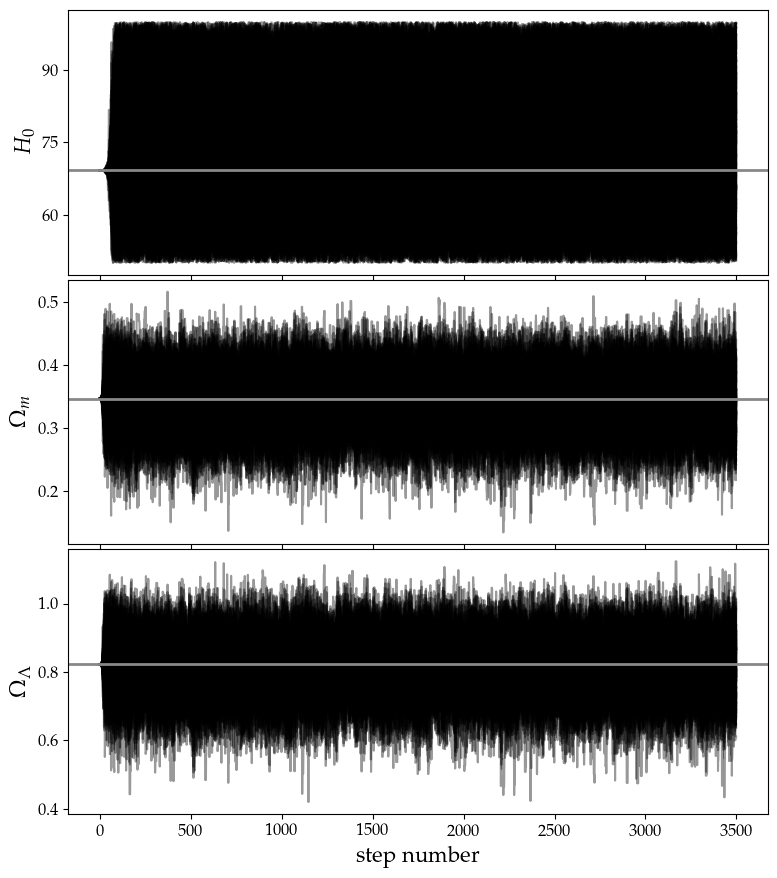

(17000, 3)


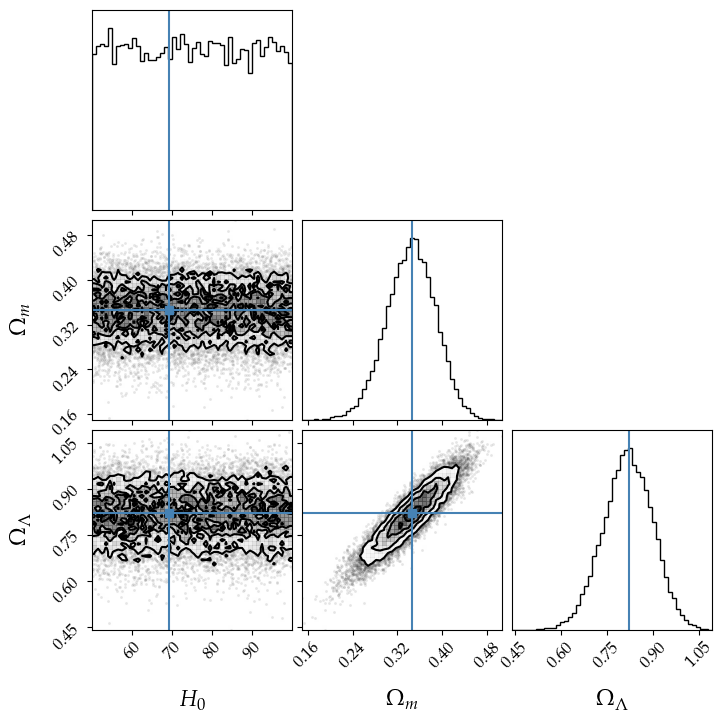

In [19]:
plot_chains(sampler1,par_ml1,parlabtex1)
samples1 = burninthin(sampler1,tau1)
plot_cornertriangle(samples1,parlabtex1,par_ml1)

In [20]:
MC_result(samples1,par_ml1, parnames1)

MCMC result:
H0 = 74.92363 +17.14378 +23.86578 -17.13034 -23.76301 (median: 74.93085, ml: 69.19300)
wm = 0.34356 +0.04374 +0.08486 -0.04370 -0.09121 (median: 0.34477, ml: 0.34598)
wl = 0.81675 +0.08104 +0.15668 -0.08098 -0.16558 (median: 0.81802, ml: 0.82258)


In [21]:
gsamples1 = MCSamples(samples=samples1,names=parnames1,labels=parlabels1)
gsamples1.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


In [ ]:
g = plots.getSubplotPlotter(width_inch=10)

g.triangle_plot([gsamplesHzC], filled=False, legend_labels=['Sem correção'], legend_loc="upper right")
g.fig.suptitle(r"O$\Lambda$CDM", fontsize=22, y=1.02)

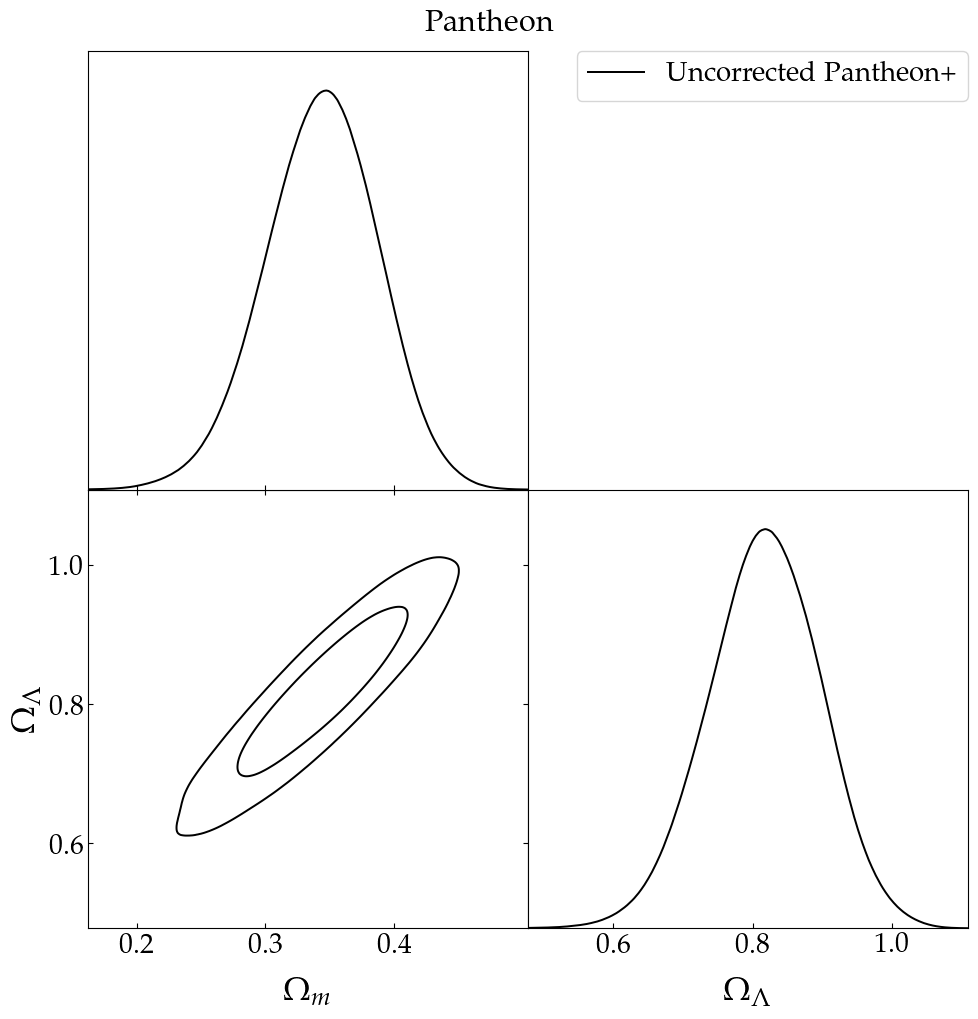

In [23]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamples1], ('wm', 'wl'), filled=False,legend_labels=['Uncorrected Pantheon+'])
g.fig.suptitle(r"Pantheon", fontsize=22, y=1.02)
g.export('Pantheon-no-f.pdf')

In [24]:
sampler = run_emcee(par_ml,100,lnprob,2.0,nstep)

100%|███████████████████████████████████████| 3500/3500 [19:00<00:00,  3.07it/s]

Acceptance fraction: [0.53914286 0.55257143 0.542      0.54971429 0.56285714 0.53971429
 0.54571429 0.54714286 0.55657143 0.53828571 0.56714286 0.56342857
 0.54685714 0.54257143 0.53685714 0.54057143 0.56085714 0.53628571
 0.56028571 0.548      0.55571429 0.54857143 0.55571429 0.56485714
 0.52771429 0.55342857 0.54371429 0.55942857 0.55285714 0.54971429
 0.54857143 0.53828571 0.538      0.55142857 0.53485714 0.56685714
 0.55342857 0.54514286 0.562      0.52428571 0.57114286 0.53285714
 0.548      0.56       0.54314286 0.54828571 0.55485714 0.54257143
 0.55314286 0.56285714 0.56542857 0.55685714 0.55457143 0.53914286
 0.56314286 0.54971429 0.54257143 0.564      0.56571429 0.53
 0.54057143 0.56657143 0.53771429 0.55114286 0.53314286 0.55257143
 0.542      0.54685714 0.57085714 0.54171429 0.52628571 0.53428571
 0.556      0.57314286 0.55771429 0.53485714 0.55028571 0.55885714
 0.55371429 0.53828571 0.53914286 0.53257143 0.55057143 0.55
 0.55371429 0.53771429 0.56628571 0.54885714 0.566857

In [25]:
tau = sampler.get_autocorr_time(tol=0)
print(tau)
taumax = np.amax(tau)
r = nstep/taumax
print(r)
if(r>50):
    print('Convergiu! :)')
else:
    print('Nao convergiu... :(')

[58.61872845 45.06971909 43.1863334  46.58603547]
59.70787993175109
Convergiu! :)


<Figure size 640x480 with 0 Axes>

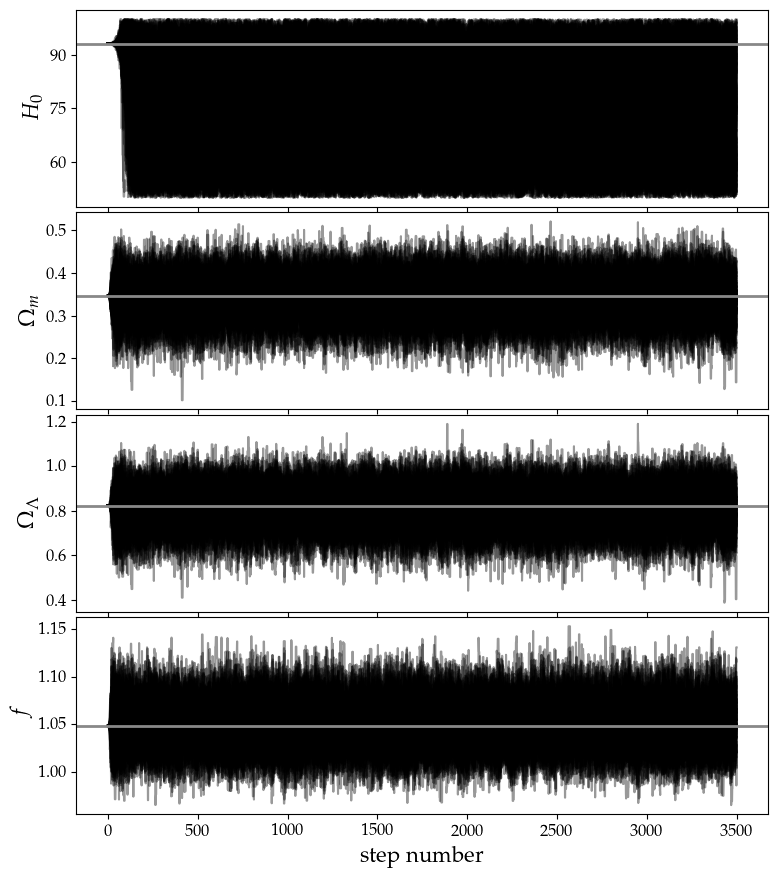

(16100, 4)


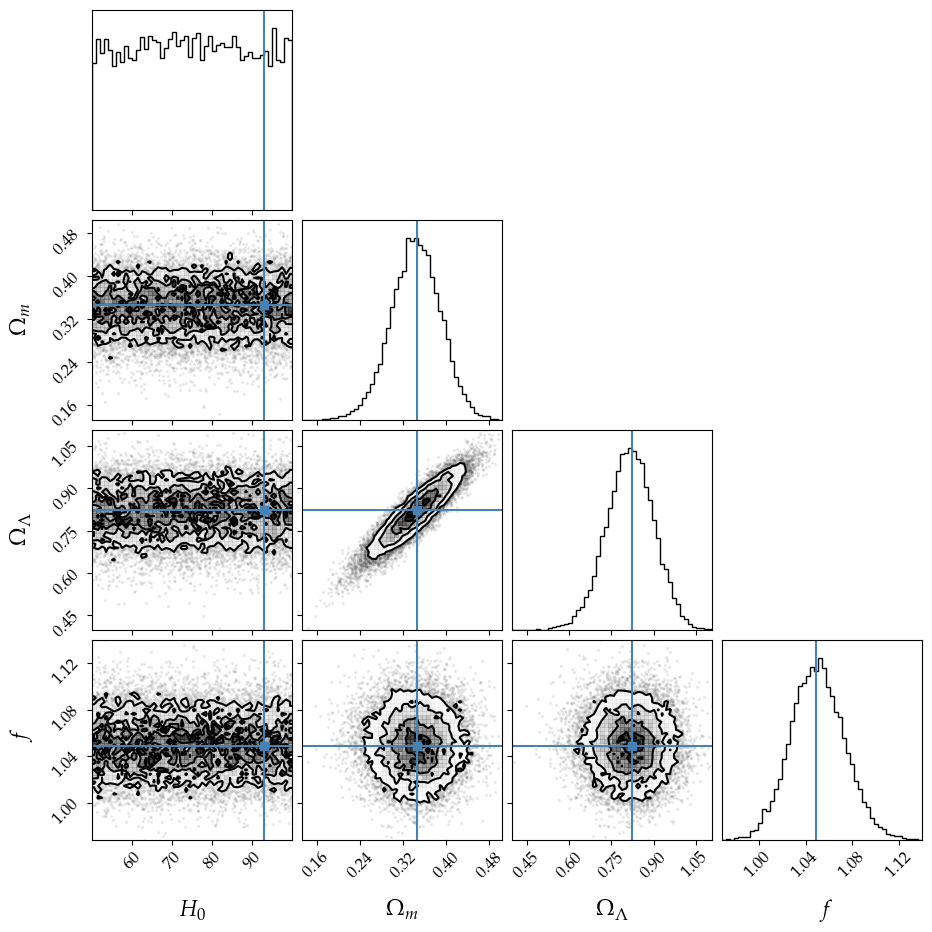

In [28]:
plot_chains(sampler,par_ml,parlabtex)
samples = burninthin(sampler,tau)
plot_cornertriangle(samples,parlabtex,par_ml)

In [29]:
MC_result(samples, par_ml, parnames)

MCMC result:
H0 = 74.99617 +16.97569 +23.89873 -16.81054 -23.79341 (median: 74.93643, ml: 93.09487)
wm = 0.34271 +0.04607 +0.09073 -0.04531 -0.09533 (median: 0.34341, ml: 0.34589)
wl = 0.81519 +0.08461 +0.16574 -0.08405 -0.17683 (median: 0.81651, ml: 0.82247)
f = 1.05021 +0.02311 +0.04749 -0.02262 -0.04539 (median: 1.04974, ml: 1.04841)


In [30]:
gsamples = MCSamples(samples=samples,names=parnames,labels=parlabels)
gsamples.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


In [31]:
gsamples = MCSamples(samples=samples,names=parnames,labels=parlabels)
gsamples.updateSettings({'contours': [0.682689492137, 0.954499736104, 0.997300203937]})

Removed no burn in


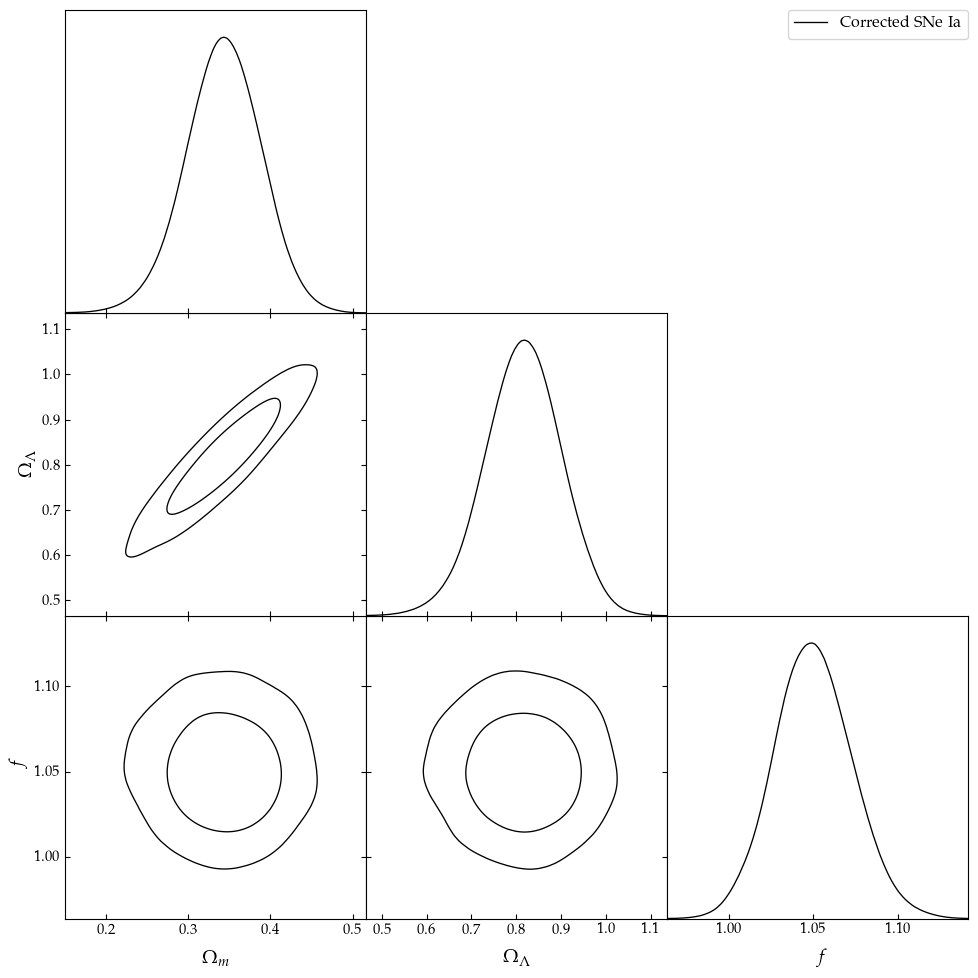

In [32]:
g = plots.getSubplotPlotter(width_inch=10)
g.triangle_plot([gsamples], ['wm','wl','f'], filled=False, legend_labels=['Corrected SNe Ia'])
g.export('fig/g_NoH0-triangle.pdf')
pl.show()

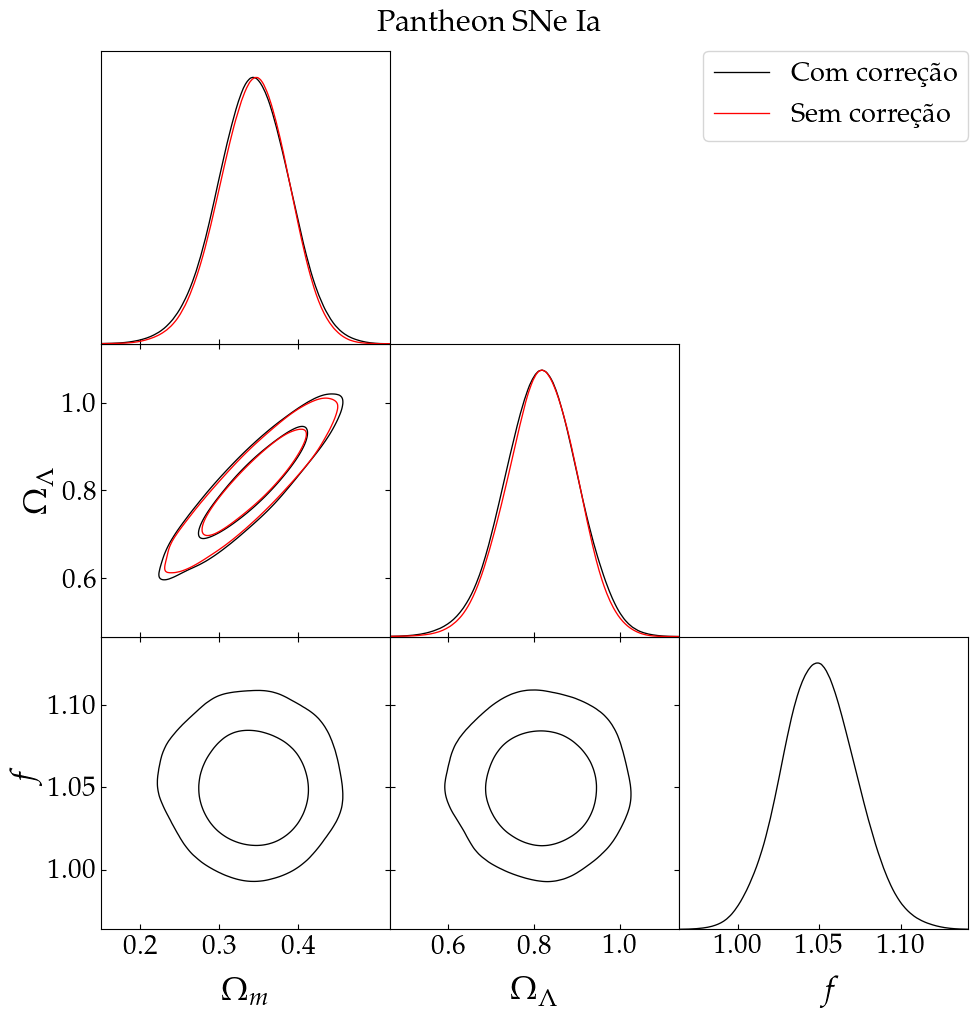

In [50]:
g = plots.getSubplotPlotter(width_inch=10)
g.settings.axes_fontsize = 20     # Aumenta os Rótulos (H0, Wm...)
g.settings.axes_labelsize = 24    # Aumenta os Números dos eixos
g.settings.legend_fontsize = 20
g.triangle_plot([gsamples, gsamples1], ['wm','wl','f'], filled=False, legend_labels=['Com correção', 'Sem correção'])
g.fig.suptitle(r"Pantheon SNe Ia", fontsize=22, y=1.02)
g.export('pantheon.pdf')
pl.show()

In [36]:
ndim1 = len(parnames1)
for i in range(ndim1):
    for j in range(1,4):
        print(gsamples1.getInlineLatex(parnames1[i],limit=j))
        
print(gsamples1.getTable().tableTex())

H_0 = 75\pm 10
H_0 = 75^{+20}_{-20}
H_0 = 75^{+30}_{-20}
\Omega_m = 0.344^{+0.046}_{-0.042}
\Omega_m = 0.344^{+0.085}_{-0.091}
\Omega_m = 0.34^{+0.12}_{-0.14}
\Omega_\Lambda = 0.817^{+0.085}_{-0.077}
\Omega_\Lambda = 0.82^{+0.16}_{-0.17}
\Omega_\Lambda = 0.82^{+0.23}_{-0.27}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$H_0            $} & $75^{+20}_{-20}            $\\

{\boldmath$\Omega_m       $} & $0.344^{+0.085}_{-0.091}   $\\

{\boldmath$\Omega_\Lambda $} & $0.82^{+0.16}_{-0.17}      $\\
\hline
\end{tabular}


In [37]:
for i in range(ndim):
    for j in range(1,4):
        print(gsamples.getInlineLatex(parnames[i],limit=j))
        
print(gsamples.getTable().tableTex())

H_0 = 75\pm 10
H_0 = 75^{+20}_{-20}
H_0 = 75^{+20}_{-20}
\Omega_m = 0.343\pm 0.046
\Omega_m = 0.343^{+0.091}_{-0.095}
\Omega_m = 0.34^{+0.14}_{-0.15}
\Omega_\Lambda = 0.815\pm 0.085
\Omega_\Lambda = 0.82^{+0.17}_{-0.18}
\Omega_\Lambda = 0.82^{+0.25}_{-0.28}
f = 1.050\pm 0.023
f = 1.050^{+0.047}_{-0.045}
f = 1.050^{+0.072}_{-0.066}
\begin{tabular} { l  c}

 Parameter &  95\% limits\\
\hline
{\boldmath$H_0            $} & $75^{+20}_{-20}            $\\

{\boldmath$\Omega_m       $} & $0.343^{+0.091}_{-0.095}   $\\

{\boldmath$\Omega_\Lambda $} & $0.82^{+0.17}_{-0.18}      $\\

{\boldmath$f              $} & $1.050^{+0.047}_{-0.045}   $\\
\hline
\end{tabular}


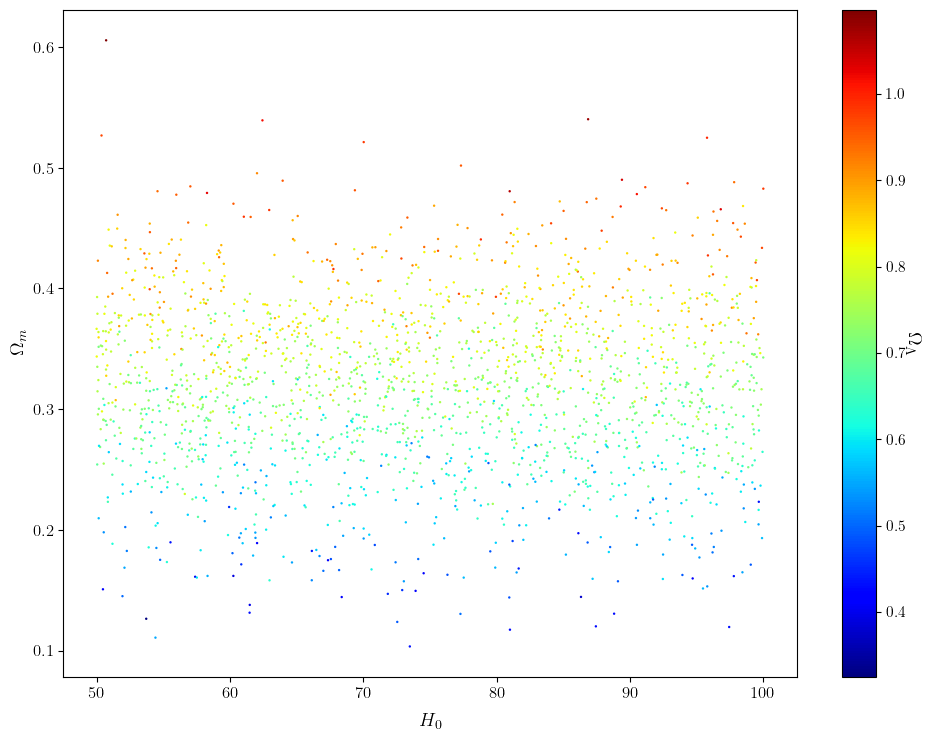

In [42]:
#2D scatter (3D) plot
g = plots.getSinglePlotter(width_inch=10)
g.settings.axes_fontsize = 12
g.plot_3d(gsamples, parnames)
pl.show()